In [13]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cmocean.cm as cm
import numpy as np

In [14]:
file_iona = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20231010_iona.nc")
print(file_iona.data_vars)
print(file_iona.coords)
print(file_iona.dims)

Data variables:
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    NH3              (time_counter, y, x) float64 34MB ...
    dSi              (time_counter, y, x) float64 34MB ...
    diatoms          (time_counter, y, x) float64 34MB ...
    nanoflagellates  (time_counter, y, x) float64 34MB ...
    Z1               (time_counter, y, x) float64 34MB ...
    PON              (time_counter, y, x) float64 34MB ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time

In [15]:
file_usa = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc")
# file_usa = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/wwtp_data_mohamedali_etal_2020.nc")
print(file_usa.data_vars)
print(file_usa.coords)
print(file_usa.dims)

Data variables:
    nav_lon      (time_counter, y, x) float32 17MB ...
    nav_lat      (time_counter, y, x) float32 17MB ...
    area         (time_counter, y, x) float64 34MB ...
    flux         (time_counter, y, x) float64 34MB ...
    temperature  (time_counter, y, x) float64 34MB ...
    NO3          (time_counter, y, x) float64 34MB ...
    NH3          (time_counter, y, x) float64 34MB ...
    oxygen       (time_counter, y, x) float64 34MB ...
    alkalinity   (time_counter, y, x) float64 34MB ...
    DIC          (time_counter, y, x) float64 34MB ...
    PON          (time_counter, y, x) float64 34MB ...
    DON          (time_counter, y, x) float64 34MB ...
Coordinates:
  * time_counter  (time_counter) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
FrozenMappingWarningOnValuesAccess({'time_counter': 12, 'y': 898, 'x': 398})


In [16]:
wwtp_locs = file_usa[["nav_lon", "nav_lat"]].to_dataframe().reset_index()
wwtp_locs = wwtp_locs.dropna(subset=["nav_lon", "nav_lat"])
wwtp_locs

,time_counter,y,x,nav_lon,nav_lat
0,1,0,0,0.0,0.0
1,1,0,1,0.0,0.0
2,1,0,2,0.0,0.0
3,1,0,3,0.0,0.0
4,1,0,4,0.0,0.0
...,...,...,...,...,...
4288843,12,897,393,0.0,0.0
4288844,12,897,394,0.0,0.0
4288845,12,897,395,0.0,0.0
4288846,12,897,396,0.0,0.0


In [17]:
bathy = xr.open_dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
print(bathy)

<xarray.Dataset> Size: 9MB
Dimensions:     (y: 898, x: 398)
Dimensions without coordinates: y, x
Data variables:
    nav_lon     (y, x) float64 3MB ...
    nav_lat     (y, x) float64 3MB ...
    Bathymetry  (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        Bathymetry 202108
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       bathymetry/Process202108Bathymetry.ipynb
    references:   grid/bathymetry_202108.nc
    history:      [2021-08-06 09:57:36] Created netCDF4 zlib=True dataset.
    comment:      Bathymetry processed from Michaels New Full River Bathymetr...


/tmp/ipykernel_720652/2451533807.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=45)
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


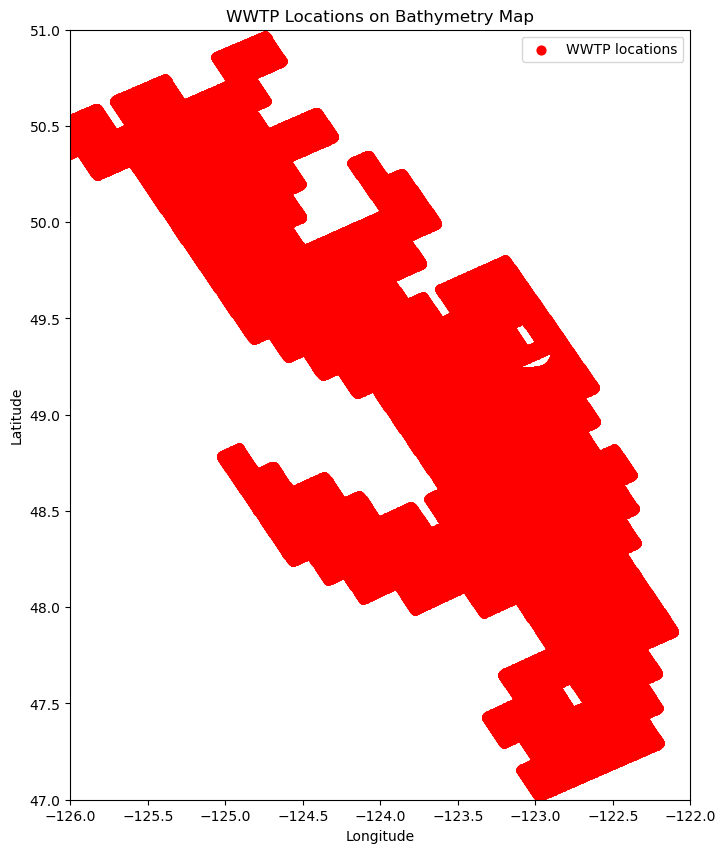

In [18]:
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=45)

ax.scatter(wwtp_locs["nav_lon"],wwtp_locs["nav_lat"],color="red",s=40,label="WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126,-122)
ax.set_ylabel("Latitude")
ax.set_ylim(47,51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [19]:
flux_max = file_usa["flux"].max(dim="time_counter") # keeps the maximum flux at each grid cell

print(flux_max.dims)
print(flux_max.shape)

('y', 'x')
(898, 398)


In [20]:
flux_nonzero = flux_max > 0
all_y, all_x = np.where(flux_nonzero.values)
print(f"Found {len(all_y)} sources")

Found 94 sources


In [21]:
lon = file_usa["nav_lon"].values
lat = file_usa["nav_lat"].values

print(lon.shape)
print(lat.shape)

(12, 898, 398)
(12, 898, 398)


In [22]:
# Get longitude and latitude grid because we only need one copy of the grid
lon = file_usa["nav_lon"].isel(time_counter=0).values
lat = file_usa["nav_lat"].isel(time_counter=0).values
print(lon.shape)
print(lat.shape)

(898, 398)
(898, 398)


In [23]:
wwtp_locs = pd.DataFrame({"y": all_y,"x": all_x,"lon": lon[all_y, all_x],"lat": lat[all_y, all_x],"max_flux": flux_max.values[all_y, all_x]})

wwtp_locs.head()

,y,x,lon,lat,max_flux
0,1,149,-122.640366,47.143044,0.000771
1,4,101,-122.905167,47.064884,0.002665
2,7,163,-122.585480,47.193027,0.003930
3,10,106,-122.897858,47.097782,0.000003
4,11,194,-122.433891,47.266994,0.004629


/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


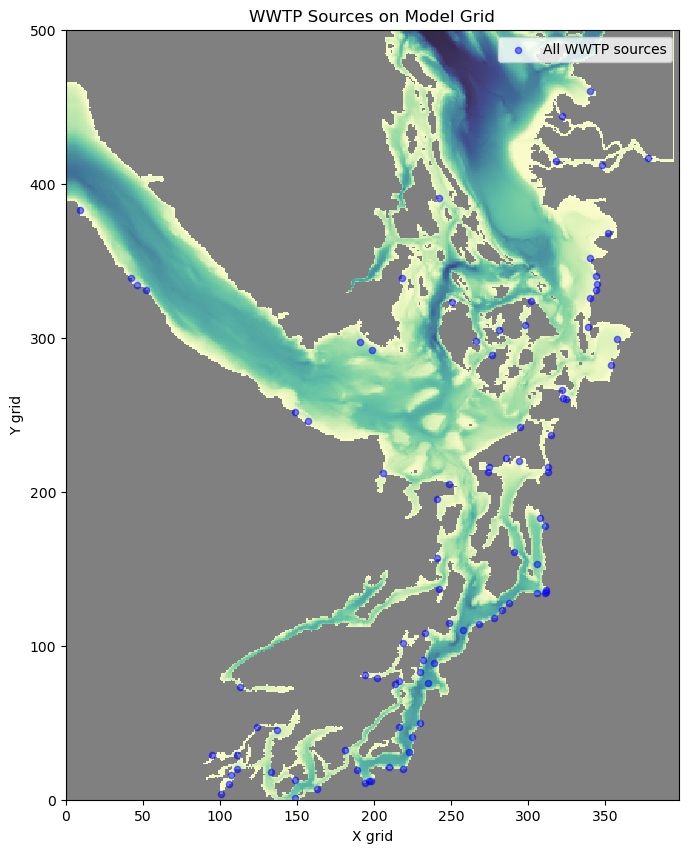

In [24]:
mycmap = cm.deep.copy()
mycmap.set_bad("grey")

fig, ax_map = plt.subplots(figsize=(8, 10))

bathy_data = bathy.variables["Bathymetry"][:]

ax_map.pcolormesh(bathy_data,cmap=mycmap,vmin=0,vmax=450)
ax_map.scatter(wwtp_locs["x"],wwtp_locs["y"],color="blue",alpha=0.5,s=20,label="All WWTP sources")
ax_map.set_title("WWTP Sources on Model Grid")
ax_map.set_xlabel("X grid")
ax_map.set_ylabel("Y grid")
ax_map.set_ylim(0, 500)
ax_map.legend()
ax_map.set_aspect("equal")

plt.show()

/tmp/ipykernel_720652/2708796783.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450)


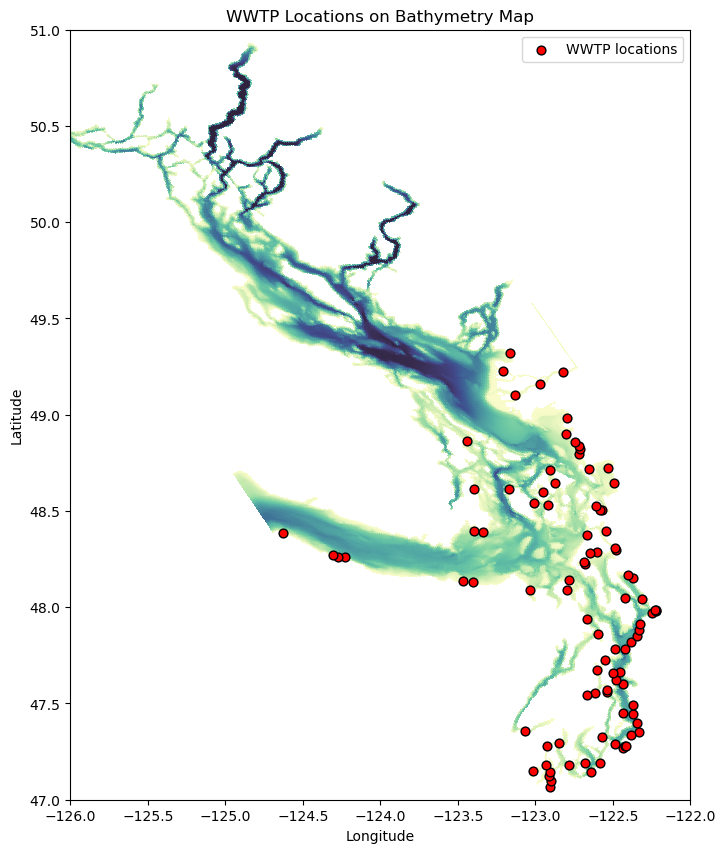

In [25]:
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450)

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126,-122)
ax.set_ylabel("Latitude")
ax.set_ylim(47,51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [26]:
iona_flux_max = file_iona["flux"].max(dim="time_counter").fillna(0)
iona_y, iona_x = np.where(iona_flux_max.values > 0)

print(f"Found {len(iona_y)} Iona source grid cell(s)")

iona_lon_grid = file_iona["nav_lon"].values
iona_lat_grid = file_iona["nav_lat"].values

iona_lon = iona_lon_grid[iona_y, iona_x]
iona_lat = iona_lat_grid[iona_y, iona_x]

print("Iona longitude:", iona_lon)
print("Iona latitude:", iona_lat)

Found 4 Iona source grid cell(s)
Iona longitude: [-123.30531  -123.30012  -123.30867  -123.303474]
Iona latitude: [49.198967 49.20085  49.202885 49.20477 ]


/tmp/ipykernel_720652/3412260971.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


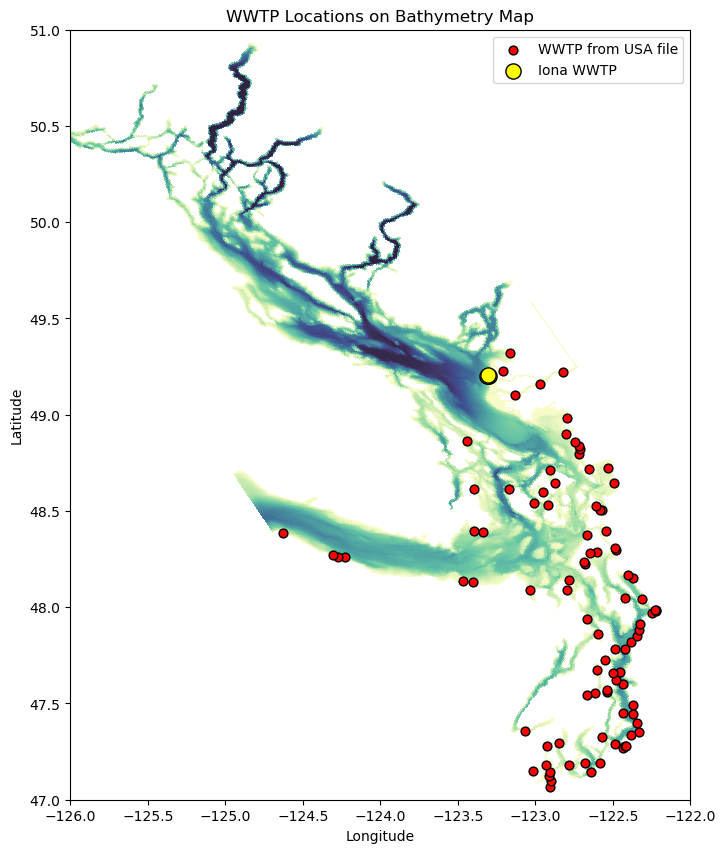

In [27]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()

In [28]:
file_canada = pd.read_csv("/home/dtaneja/analysis-dishika/notebooks/RichvsMineWWTP.csv")
file_canada.head()

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,latitude,longitude,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,BC Ferries,NaN,49.783333,-124.616670,3,"0,31",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Van Anda,NaN,49.758333,-124.550000,35,"17,2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,District of Campbell River,35519.0,50.048611,-125.258333,35,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Powell River Regional District - Lund,NaN,49.981111,-124.761111,50,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
file_canada = file_canada.rename(columns={
    "longitude": "lon",
    "latitude": "lat"
})

/tmp/ipykernel_720652/2252853920.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


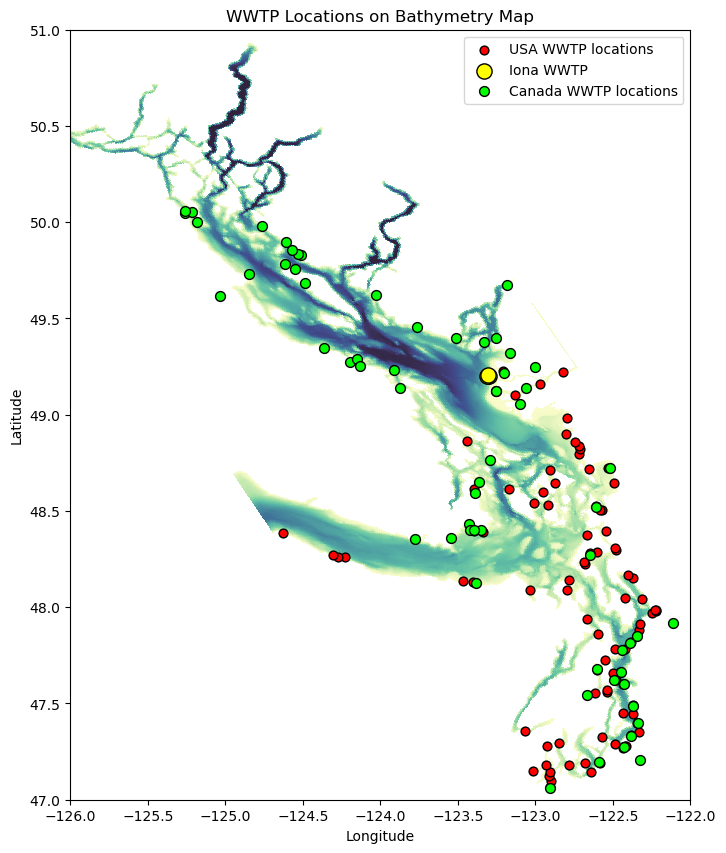

In [30]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=50,label="Canada WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()


In [31]:
# Function to calculate distance between two points given their longitude and latitude using the Haversine formula
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371  # Earth radius in km
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [32]:
threshold_km = 2
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

In [33]:
file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

Original Canada WWTP count: 62
Filtered Canada WWTP count: 40
Removed Canada WWTP count: 22


/tmp/ipykernel_720652/799666377.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


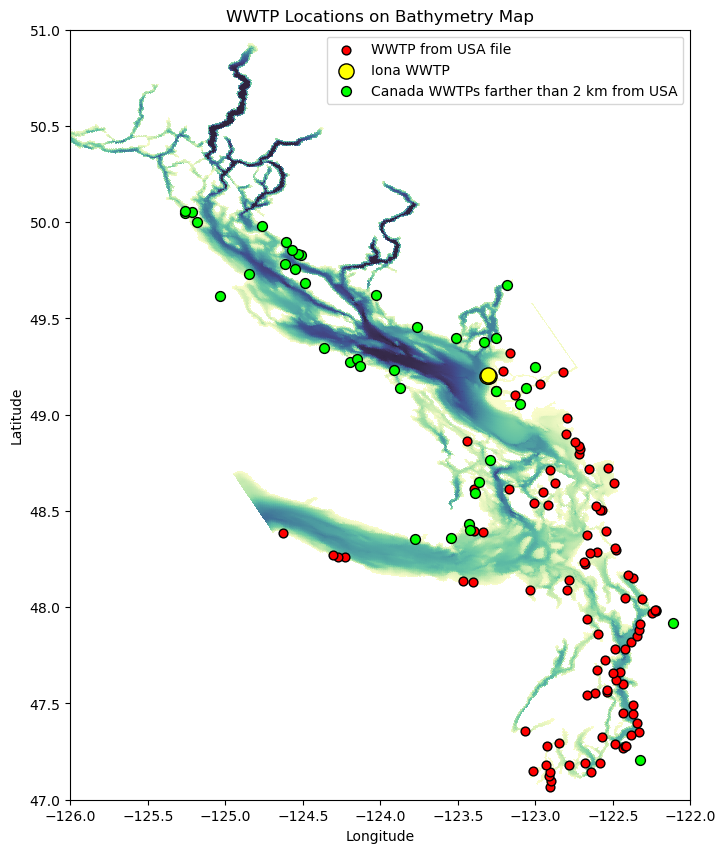

In [34]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

In [35]:
removed_canada = file_canada[file_canada["nearest_usa_distance_km"] <= threshold_km].copy()
removed_canada

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,lat,lon,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,nearest_usa_distance_km
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.510335
28,Iona,Greater Vancouver Sewerage and Drainage (Iona),NaN,49.217485,-123.201693,72-106,507000,NaN,howe,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.877626
34,Burrard_inlet,Greater Vancouver Regional District,NaN,49.321540,-123.165490,7.2,12900,NaN,howe,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000595
37,Bellingham,Bellingham,93910.0,48.723870,-122.519546,18,30520.75,NaN,fraser,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.800865
41,McLoughlin Point,McLoughlin Point WWTP,322245.0,48.400988,-123.397611,60,104730,NaN,jdf,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.572369
43,Port Angeles,Port Angeles,20200.0,48.128260,-123.379350,16,6565,NaN,jdf,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.680981
44,Anacortes,Anacortes,17880.0,48.523075,-122.609350,5811,5,NaN,skagit,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.157905
46,Bainbridge Island,Bainbridge Island,25060.0,47.622780,-122.489167,13,8144.5,NaN,puget,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.672458
47,South King,South King,714050.0,47.600585,-122.427888,190,232066,NaN,puget,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.355771
48,West King,West King,963450.0,47.661732,-122.449820,73,313121,NaN,puget,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.234890


In [36]:
threshold_km = 5
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

Original Canada WWTP count: 62
Filtered Canada WWTP count: 36
Removed Canada WWTP count: 26


/tmp/ipykernel_720652/799666377.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


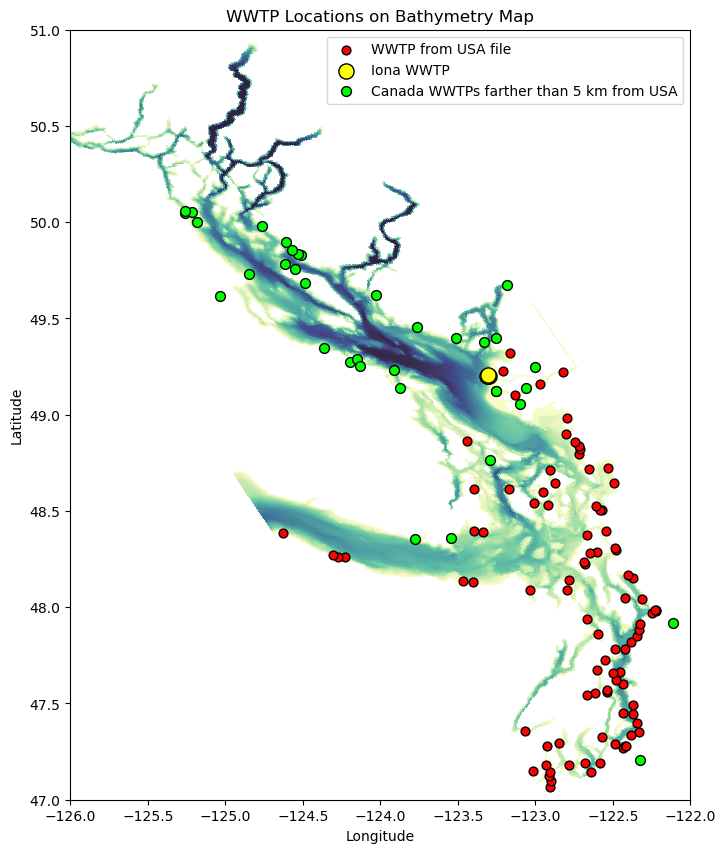

In [37]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 62
Filtered Canada WWTP count: 38
Removed Canada WWTP count: 24


/tmp/ipykernel_720652/2483870730.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


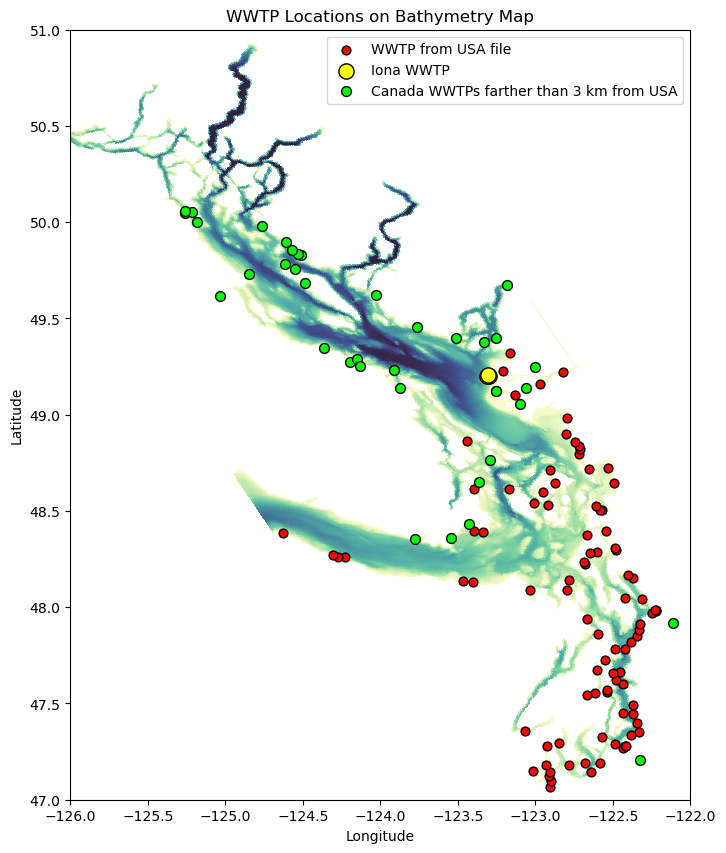

In [38]:
threshold_km = 3
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 62
Filtered Canada WWTP count: 38
Removed Canada WWTP count: 24


/tmp/ipykernel_720652/1290980534.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


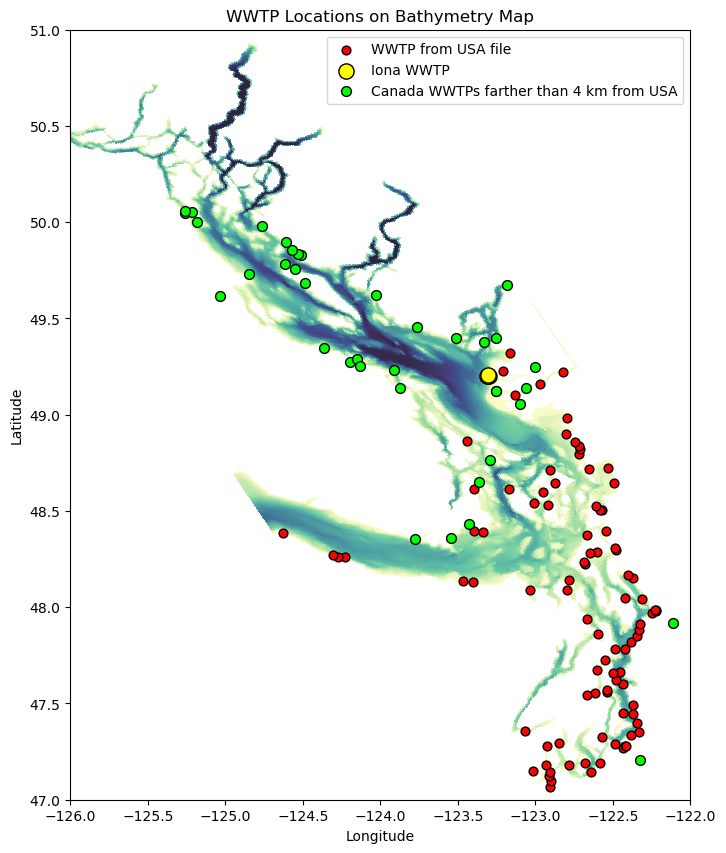

In [39]:
threshold_km = 4
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 62
Filtered Canada WWTP count: 34
Removed Canada WWTP count: 28


/tmp/ipykernel_720652/3895793859.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


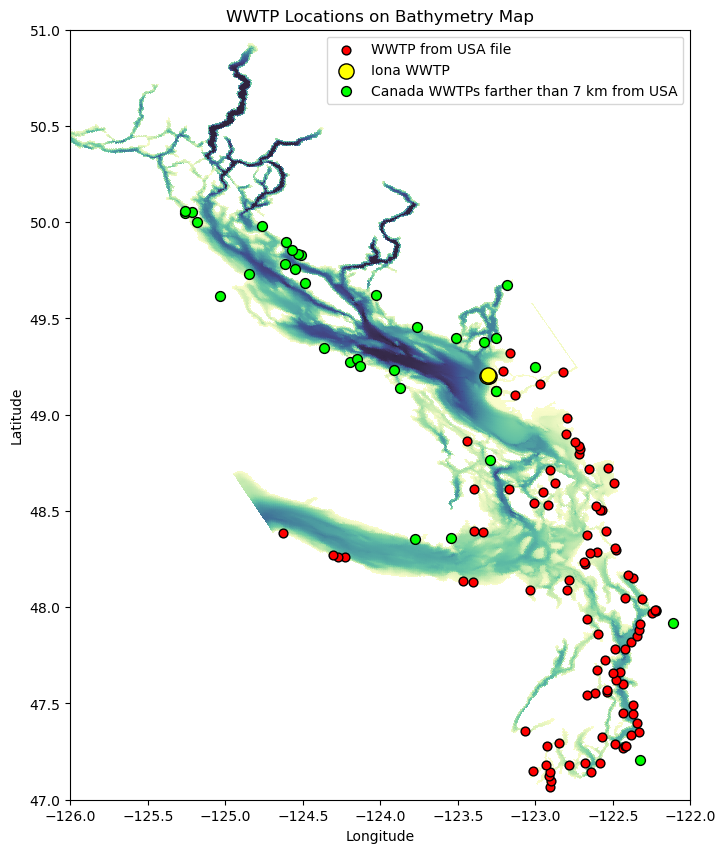

In [40]:
threshold_km = 7
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 62
Filtered Canada WWTP count: 36
Removed Canada WWTP count: 26


/tmp/ipykernel_720652/3476536819.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


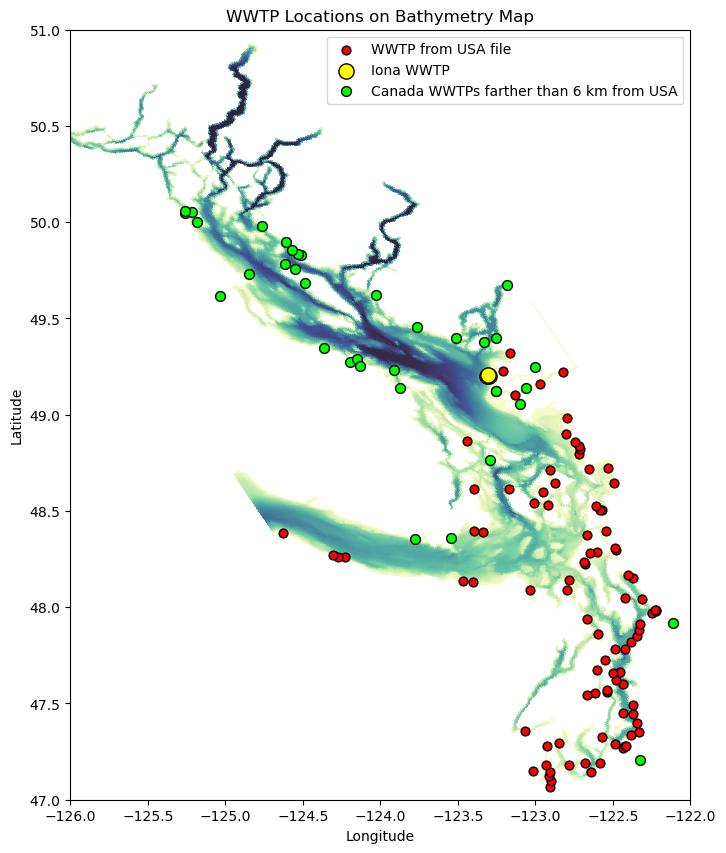

In [41]:
threshold_km = 6
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

In [42]:
bathy = xr.open_dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
print(bathy)

<xarray.Dataset> Size: 9MB
Dimensions:     (y: 898, x: 398)
Dimensions without coordinates: y, x
Data variables:
    nav_lon     (y, x) float64 3MB ...
    nav_lat     (y, x) float64 3MB ...
    Bathymetry  (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        Bathymetry 202108
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       bathymetry/Process202108Bathymetry.ipynb
    references:   grid/bathymetry_202108.nc
    history:      [2021-08-06 09:57:36] Created netCDF4 zlib=True dataset.
    comment:      Bathymetry processed from Michaels New Full River Bathymetr...


In [43]:
bathy_data = bathy["Bathymetry"]
bathy_data

<xarray.DataArray 'Bathymetry' (y: 898, x: 398)> Size: 3MB
[357404 values with dtype=float64]
Dimensions without coordinates: y, x
Attributes:
    units:      metres
    long_name:  sea_floor_depth

In [44]:
# point from CSV
point_lon = -125.03613
point_lat = 49.61634

lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]
dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
# to ignore the missing values or values where there is land
dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)

j, i = np.unravel_index(np.argmin(dist2), dist2.shape)
print("Closest bathymetry grid cell:")
print("Longitude:", lon_grid[j, i])
print("Latitude:", lat_grid[j, i])
print("Depth:", bathy_data[j, i])

Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-124.953186)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.656891)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(4.)
Attributes:
    units:      metres
    long_name:  sea_floor_depth


/tmp/ipykernel_720652/2235726124.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


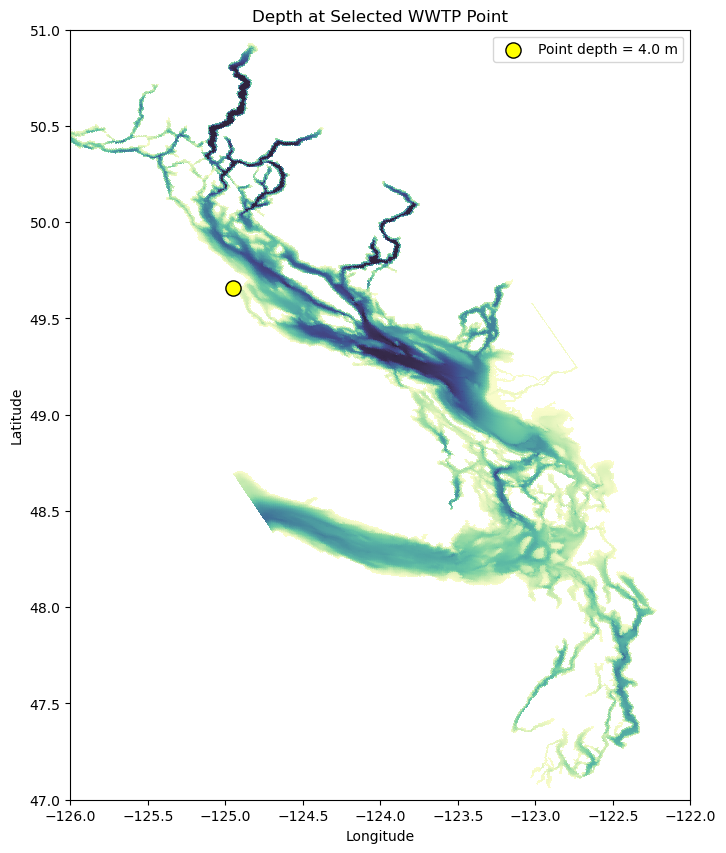

In [45]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(lon_grid[j, i],lat_grid[j, i],color="yellow",edgecolors="black",s=120,label=f"Point depth = {bathy_data[j, i]:.1f} m")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("Depth at Selected WWTP Point")
ax.legend()
plt.show()

49.62344262403062, -125.0118078547288

Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-124.953186)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.656891)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(4.)
Attributes:
    units:      metres
    long_name:  sea_floor_depth


/tmp/ipykernel_720652/1814480417.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


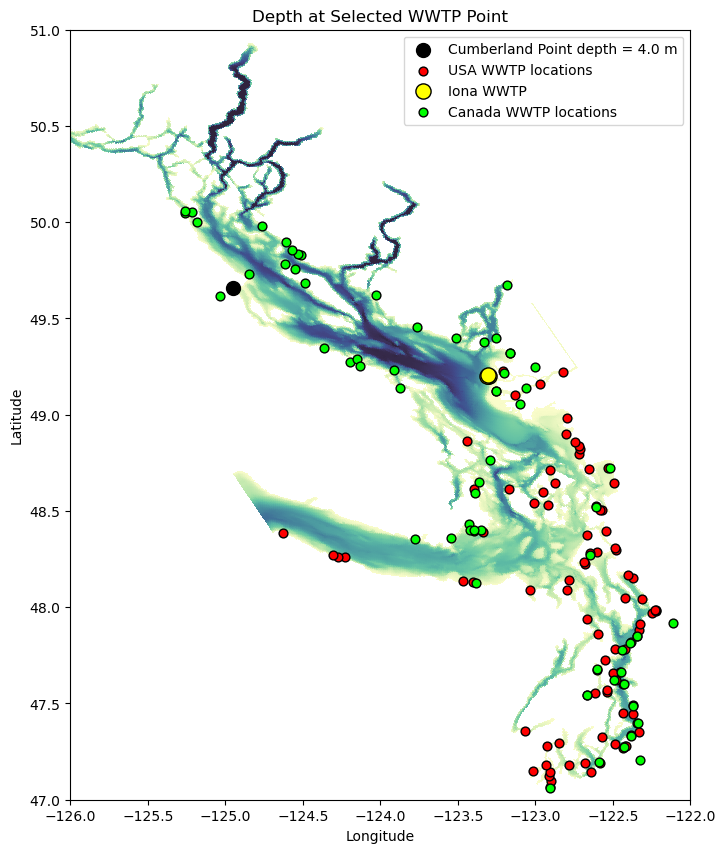

In [46]:
# Cumberland (from csv file)
point_lon = -125.03613
point_lat = 49.61634

lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]
dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
# to ignore the missing values or values where there is land
dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)

j, i = np.unravel_index(np.argmin(dist2), dist2.shape)
print("Closest bathymetry grid cell:")
print("Longitude:", lon_grid[j, i])
print("Latitude:", lat_grid[j, i])
print("Depth:", bathy_data[j, i])

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(lon_grid[j, i],lat_grid[j, i],color="black",edgecolors="black",s=100,label=f"Cumberland Point depth = {bathy_data[j, i]:.1f} m")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=40,label="Canada WWTP locations")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("Depth at Selected WWTP Point")
ax.legend()
plt.show()

Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-123.129143)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.072659)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(4.)
Attributes:
    units:      metres
    long_name:  sea_floor_depth


/tmp/ipykernel_720652/1963602021.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


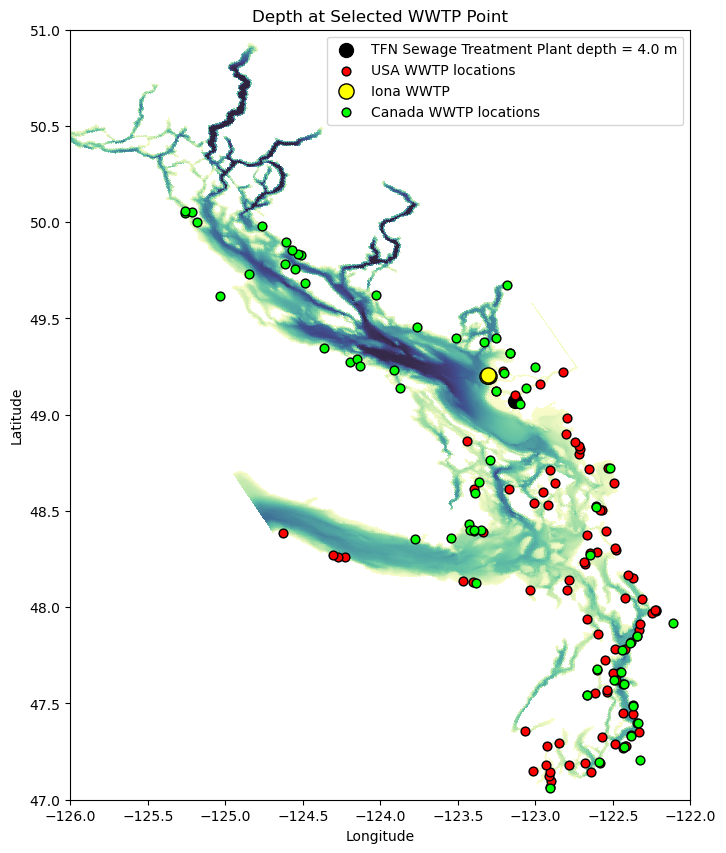

In [47]:
# TFN Sewage Treatment Plant(from csv file)
point_lon = -123.098053077777
point_lat = 49.053303965667

lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]
dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
# to ignore the missing values or values where there is land
dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)

j, i = np.unravel_index(np.argmin(dist2), dist2.shape)
print("Closest bathymetry grid cell:")
print("Longitude:", lon_grid[j, i])
print("Latitude:", lat_grid[j, i])
print("Depth:", bathy_data[j, i])

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(lon_grid[j, i],lat_grid[j, i],color="black",edgecolors="black",s=100,label=f"TFN Sewage Treatment Plant depth = {bathy_data[j, i]:.1f} m")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=40,label="Canada WWTP locations")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("Depth at Selected WWTP Point")
ax.legend()
plt.show()

Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-123.060989)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.13628)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(17.4375)
Attributes:
    units:      metres
    long_name:  sea_floor_depth


/tmp/ipykernel_720652/174373556.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


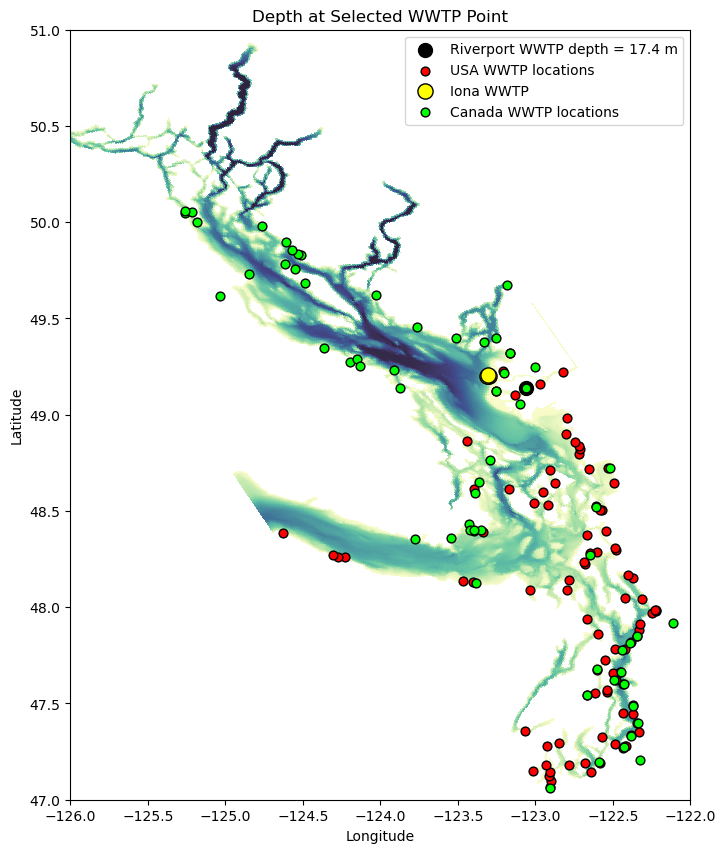

In [48]:
# Riverport WWTP (from csv file)
point_lon = -123.060988116488
point_lat = 49.1363763192682

lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]
dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
# to ignore the missing values or values where there is land
dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)

j, i = np.unravel_index(np.argmin(dist2), dist2.shape)
print("Closest bathymetry grid cell:")
print("Longitude:", lon_grid[j, i])
print("Latitude:", lat_grid[j, i])
print("Depth:", bathy_data[j, i])

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(lon_grid[j, i],lat_grid[j, i],color="black",edgecolors="black",s=100,label=f"Riverport WWTP depth = {bathy_data[j, i]:.1f} m")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=40,label="Canada WWTP locations")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("Depth at Selected WWTP Point")
ax.legend()
plt.show()

Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-123.02092)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.20079)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(6.375)
Attributes:
    units:      metres
    long_name:  sea_floor_depth


/tmp/ipykernel_720652/2174480691.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


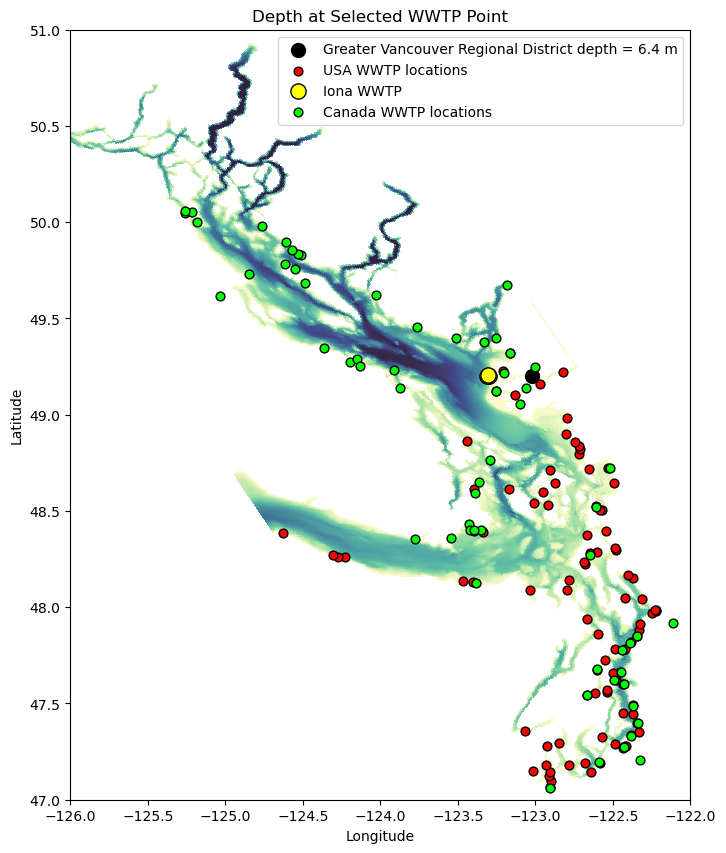

In [49]:
# Greater Vancouver Regional District (from csv file)
point_lon = -123
point_lat = 49.24972

lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]
dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
# to ignore the missing values or values where there is land
dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)

j, i = np.unravel_index(np.argmin(dist2), dist2.shape)
print("Closest bathymetry grid cell:")
print("Longitude:", lon_grid[j, i])
print("Latitude:", lat_grid[j, i])
print("Depth:", bathy_data[j, i])

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(lon_grid[j, i],lat_grid[j, i],color="black",edgecolors="black",s=100,label=f"Greater Vancouver Regional District depth = {bathy_data[j, i]:.1f} m")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=40,label="Canada WWTP locations")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("Depth at Selected WWTP Point")
ax.legend()
plt.show()

In [50]:
def find_nearest_water_point(point_lon, point_lat, lon_grid, lat_grid, bathy_data):
    dist_km = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
    water_mask = np.isfinite(bathy_data) & (bathy_data > 0)
    dist_water_only = np.where(water_mask, dist_km, np.inf)
    j, i = np.unravel_index(np.argmin(dist_water_only), dist_water_only.shape)
    return j, i

In [51]:
selected_points = [
    {
        "name": "Cumberland",
        "lon": -125.03613,
        "lat": 49.61634
    },
    {
        "name": "TFN Sewage Treatment Plant",
        "lon": -123.098053077777,
        "lat": 49.053303965667
    },
    {
        "name": "Riverport WWTP",
        "lon": -123.060988116488,
        "lat": 49.1363763192682
    },
    {
        "name": "Greater Vancouver Regional District",
        "lon": -123,
        "lat": 49.24972
    }
]

In [52]:
nearest_points = []

for p in selected_points:
    j, i = find_nearest_water_point(
        p["lon"],
        p["lat"],
        lon_grid,
        lat_grid,
        bathy_data
    )

    nearest_points.append({
        "name": p["name"],
        "original_lon": p["lon"],
        "original_lat": p["lat"],
        "water_lon": lon_grid[j, i].values,
        "water_lat": lat_grid[j, i].values,
        "depth": bathy_data[j, i],
        "j": j,
        "i": i
    })

nearest_points

[{'name': 'Cumberland',
  'original_lon': -125.03613,
  'original_lat': 49.61634,
  'water_lon': array(-124.95318604),
  'water_lat': array(49.65689087),
  'depth': <xarray.DataArray 'Bathymetry' ()> Size: 8B
  array(4.)
  Attributes:
      units:      metres
      long_name:  sea_floor_depth,
  'j': np.int64(652),
  'i': np.int64(119)},
 {'name': 'TFN Sewage Treatment Plant',
  'original_lon': -123.098053077777,
  'original_lat': 49.053303965667,
  'water_lon': array(-123.12914276),
  'water_lat': array(49.07265854),
  'depth': <xarray.DataArray 'Bathymetry' ()> Size: 8B
  array(4.)
  Attributes:
      units:      metres
      long_name:  sea_floor_depth,
  'j': np.int64(409),
  'i': np.int64(314)},
 {'name': 'Riverport WWTP',
  'original_lon': -123.060988116488,
  'original_lat': 49.1363763192682,
  'water_lon': array(-123.06098938),
  'water_lat': array(49.13628006),
  'depth': <xarray.DataArray 'Bathymetry' ()> Size: 8B
  array(17.4375)
  Attributes:
      units:      metres
      

/tmp/ipykernel_720652/741892882.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


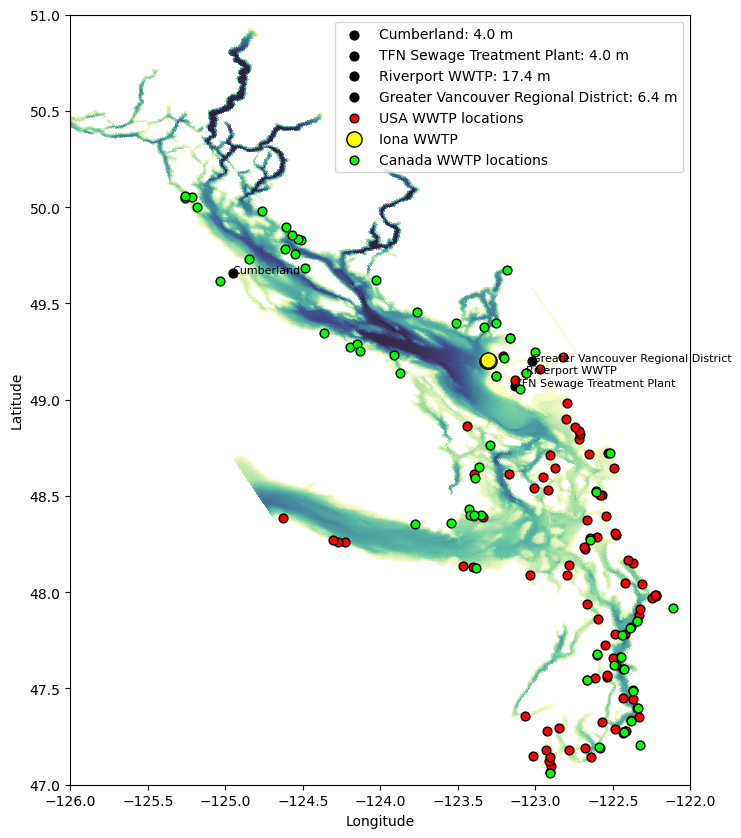

In [53]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

for p in nearest_points:
    ax.scatter(p["water_lon"],p["water_lat"],color="black",edgecolors="white",s=70,label=f'{p["name"]}: {p["depth"]:.1f} m')
    ax.text(p["water_lon"],p["water_lat"],p["name"],fontsize=8,color="black")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada["lon"],file_canada["lat"],color="lime",edgecolor="black",s=40,label="Canada WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.legend()
plt.show()

Original Canada WWTP count: 62
Filtered Canada WWTP count: 40
Removed Canada WWTP count: 22


/tmp/ipykernel_720652/2766084753.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


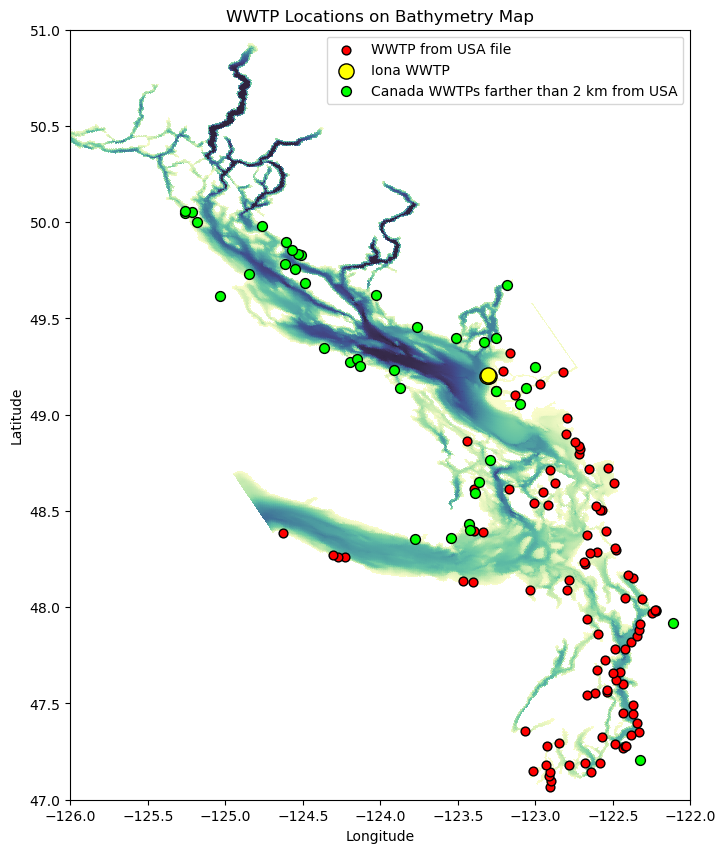

In [54]:
threshold_km = 2
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

Original Canada WWTP count: 62
Filtered Canada WWTP count: 40
Removed Canada WWTP count: 22


/tmp/ipykernel_720652/1641079832.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


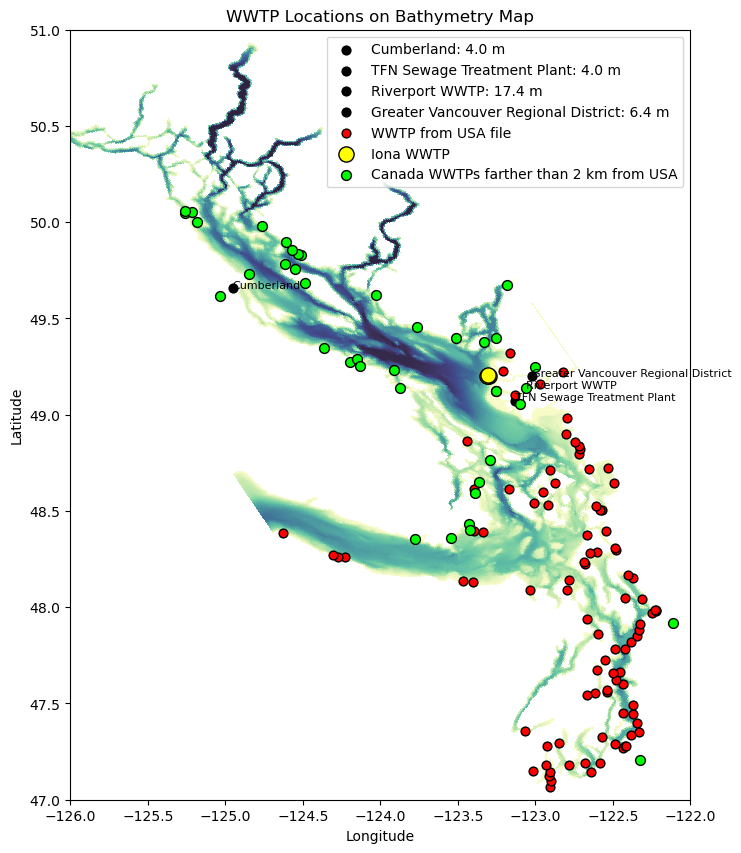

In [55]:
threshold_km = 2
min_distances = []

for _, canada_row in file_canada.iterrows():
    distances = haversine_km(canada_row["lon"],canada_row["lat"],wwtp_locs["lon"].values,wwtp_locs["lat"].values)
    min_distances.append(distances.min())

file_canada["nearest_usa_distance_km"] = min_distances

file_canada_filtered = file_canada[file_canada["nearest_usa_distance_km"] > threshold_km].copy()
print("Original Canada WWTP count:", len(file_canada))
print("Filtered Canada WWTP count:", len(file_canada_filtered))
print("Removed Canada WWTP count:", len(file_canada) - len(file_canada_filtered))

fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
for p in nearest_points:
    ax.scatter(p["water_lon"],p["water_lat"],color="black",edgecolors="white",s=70,label=f'{p["name"]}: {p["depth"]:.1f} m')
    ax.text(p["water_lon"],p["water_lat"],p["name"],fontsize=8,color="black")
ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_filtered["lon"],file_canada_filtered["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

In [56]:
file_canada_plot = file_canada_filtered.copy()

remove_mask = np.zeros(len(file_canada_plot), dtype=bool)

for p in selected_points:
    dist_to_selected = haversine_km(
        file_canada_plot["lon"],
        file_canada_plot["lat"],
        p["lon"],
        p["lat"]
    )
    
    # remove points within 50 metres of selected original point
    remove_mask = remove_mask | (dist_to_selected < 0.05)

file_canada_plot = file_canada_plot[~remove_mask]

/tmp/ipykernel_720652/3615401188.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


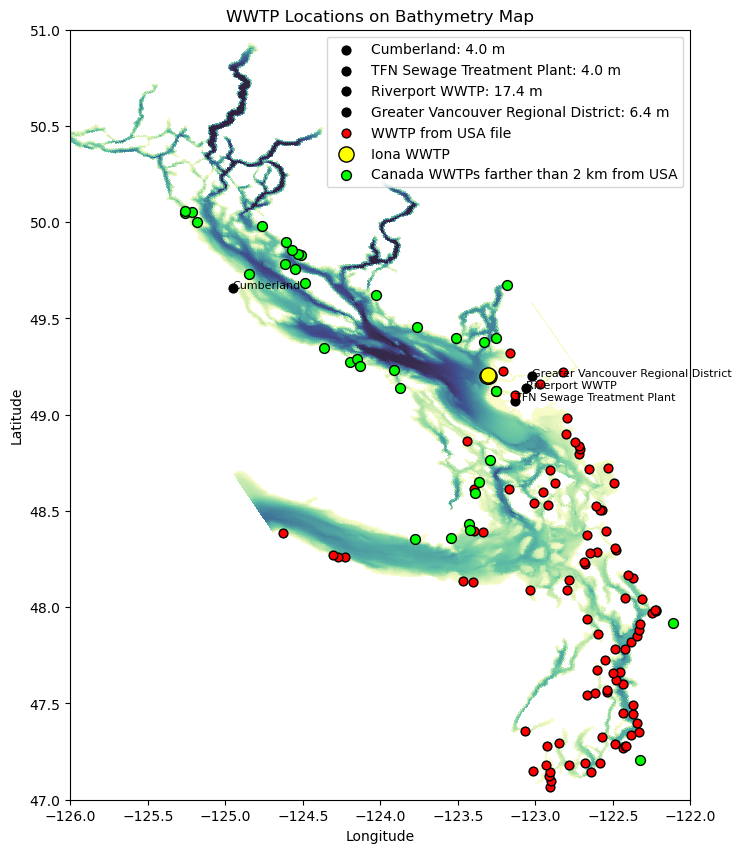

In [57]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
for p in nearest_points:
    ax.scatter(p["water_lon"],p["water_lat"],color="black",edgecolors="white",s=70,label=f'{p["name"]}: {p["depth"]:.1f} m')
    ax.text(p["water_lon"],p["water_lat"],p["name"],fontsize=8,color="black")
ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="WWTP from USA file")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(file_canada_plot["lon"],file_canada_plot["lat"],color="lime",edgecolors="black",s=50,label=f"Canada WWTPs farther than {threshold_km} km from USA")

ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()

plt.show()

In [58]:
print(file_usa.data_vars)
print(file_usa.coords)
print(file_usa.dims)

Data variables:
    nav_lon      (time_counter, y, x) float32 17MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    nav_lat      (time_counter, y, x) float32 17MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    area         (time_counter, y, x) float64 34MB ...
    flux         (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    temperature  (time_counter, y, x) float64 34MB ...
    NO3          (time_counter, y, x) float64 34MB ...
    NH3          (time_counter, y, x) float64 34MB ...
    oxygen       (time_counter, y, x) float64 34MB ...
    alkalinity   (time_counter, y, x) float64 34MB ...
    DIC          (time_counter, y, x) float64 34MB ...
    PON          (time_counter, y, x) float64 34MB ...
    DON          (time_counter, y, x) float64 34MB ...
Coordinates:
  * time_counter  (time_counter) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
FrozenMappingWarningOnValuesAccess({'time_counter': 12, 'y': 898, 'x': 398})


In [59]:
mesh = xr.open_dataset("/ocean/atall/MOAD/grid/mesh_mask202108.nc")
print(mesh)

<xarray.Dataset> Size: 788MB
Dimensions:       (y: 898, x: 398, t: 1, z: 40)
Dimensions without coordinates: y, x, t, z
Data variables: (12/43)
    nav_lon       (y, x) float32 1MB ...
    nav_lat       (y, x) float32 1MB ...
    time_counter  (t) datetime64[ns] 8B ...
    tmask         (t, z, y, x) int8 14MB ...
    umask         (t, z, y, x) int8 14MB ...
    vmask         (t, z, y, x) int8 14MB ...
    ...            ...
    gdepv         (t, z, y, x) float32 57MB ...
    gdepw_0       (t, z, y, x) float32 57MB ...
    gdept_1d      (t, z) float64 320B ...
    gdepw_1d      (t, z) float64 320B ...
    e3t_1d        (t, z) float64 320B ...
    e3w_1d        (t, z) float64 320B ...
Attributes:
    file_name:    grid/mesh_mask202108.nc
    TimeStamp:    07/08/2021 17:25:49 -0700
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO bathymetry_202108 Bathymetry Mesh Mask
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO-3.6 S

In [60]:
mesh["tmask"]
mesh["tmask"].shape

(1, 40, 898, 398)

In [61]:
tmask_2d = mesh["tmask"].values[0, 0, :, :]
print(tmask_2d.shape)

(898, 398)


In [62]:
lon_2d = np.squeeze(lon_grid)
lat_2d = np.squeeze(lat_grid)

In [63]:
def get_land_water_status(point_lon, point_lat):
    dist = haversine_km(lon_2d, lat_2d, point_lon, point_lat)
    j, i = np.unravel_index(np.nanargmin(dist), dist.shape)
    mask_value = int(tmask_2d[j, i])

    if mask_value == 1:
        return "water"
    elif mask_value == 0:
        return "land"
    else:
        return "unknown"

canada_status = file_canada[["Outfall Name from Rich", "lat", "lon","Depth"]].copy()
canada_status["status"] = canada_status.apply(
    lambda row: get_land_water_status(row["lon"], row["lat"]),
    axis=1
)

canada_status

,Outfall Name from Rich,lat,lon,Depth,status
0,Capital Regional District - Clover Point,48.402500,-123.348889,67,water
1,BC Ferries,49.783333,-124.616670,3,land
2,Van Anda,49.758333,-124.550000,35,land
3,District of Campbell River,50.048611,-125.258333,35,water
4,Powell River Regional District - Lund,49.981111,-124.761111,50,land
...,...,...,...,...,...
57,Lynwood,47.848000,-122.343287,30,land
58,brightwater,47.777687,-122.440064,182,water
59,Oak harbour,48.270610,-122.647762,10,water
60,Kitsap,47.677189,-122.602822,12.5,water


In [64]:
(canada_status["status"]=="water").sum()

np.int64(37)

/tmp/ipykernel_720652/3537541431.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


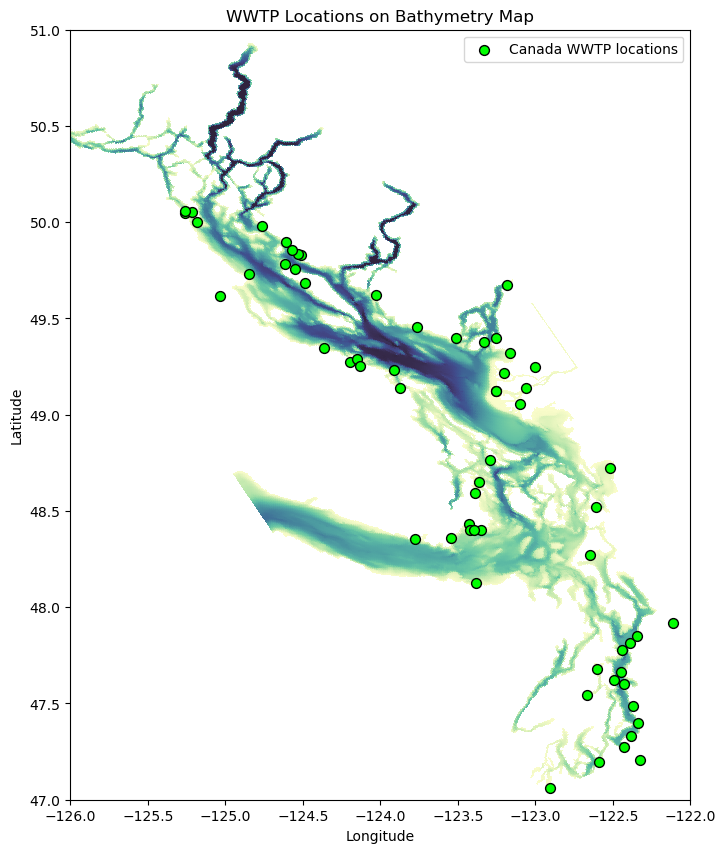

In [65]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
ax.scatter(canada_status["lon"],canada_status["lat"],color="lime",edgecolor="black",s=50,label="Canada WWTP locations")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()


In [66]:
for _, row in canada_status.iterrows():
    if row["status"] == "land":
        point_lon = row["lon"]
        point_lat = row["lat"]
        dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
        dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)
        j, i = np.unravel_index(np.argmin(dist2), dist2.shape)
        print(f"Point '{row['Outfall Name from Rich']}' at ({row['lon']}, {row['lat']}) is on land. Nearest water point:")
        print("Closest bathymetry grid cell:")
        print("Longitude:", lon_grid[j, i])
        print("Latitude:", lat_grid[j, i])
        print("Depth:", bathy_data[j, i])
    else:
        print(f"Point at ({row['lon']}, {row['lat']}) is already in water, no adjustment needed.")

Point at (-123.348889, 48.4025) is already in water, no adjustment needed.
Point 'BC Ferries' at (-124.61667, 49.783333) is on land. Nearest water point:
Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-124.626236)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.775177)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(22.)
Attributes:
    units:      metres
    long_name:  sea_floor_depth
Point 'Van Anda' at (-124.55, 49.758333) is on land. Nearest water point:
Closest bathymetry grid cell:
Longitude: <xarray.DataArray 'nav_lon' ()> Size: 8B
array(-124.553001)
Attributes:
    units:      degrees_east
    long_name:  longitude
Latitude: <xarray.DataArray 'nav_lat' ()> Size: 8B
array(49.76078)
Attributes:
    units:      degrees_north
    long_name:  latitude
Depth: <xarray.DataArray 'Bathymetry' 

In [79]:
nearest_rows = []

for _, row in canada_status.iterrows():
    point_lon = row["lon"]
    point_lat = row["lat"]

    if row["status"] == "land":
        dist2 = haversine_km(lon_grid, lat_grid, point_lon, point_lat)
        dist2 = np.where(np.isfinite(bathy_data), dist2, np.inf)
        j, i = np.unravel_index(np.argmin(dist2), dist2.shape)

        nearest_rows.append({
            "nearest_lon": lon_grid[j, i],
            "nearest_lat": lat_grid[j, i],
            "nearest_depth": float(bathy_data[j, i]),
            "moved": True
        })

    else:
        nearest_rows.append({
            "nearest_lon": point_lon,
            "nearest_lat": point_lat,
            "nearest_depth": np.nan,
            "moved": False
        })

nearest_df = pd.DataFrame(nearest_rows)

canada_plot = pd.concat(
    [canada_status.reset_index(drop=True), nearest_df.reset_index(drop=True)],
    axis=1
)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
canada_plot

,Outfall Name from Rich,lat,lon,Depth,status,nearest_lon,nearest_lat,nearest_depth,moved
0,Capital Regional District - Clover Point,48.402500,-123.348889,67,water,-123.348889,48.4025,NaN,False
1,BC Ferries,49.783333,-124.616670,3,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,22.0000,True
2,Van Anda,49.758333,-124.550000,35,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,75.0625,True
3,District of Campbell River,50.048611,-125.258333,35,water,-125.258333,50.048611,NaN,False
4,Powell River Regional District - Lund,49.981111,-124.761111,50,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,54.1875,True
5,Quathiaski Cove,50.051000,-125.217000,24,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,28.3750,True
6,Sliammon,49.896944,-124.608333,15,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,9.7500,True
7,Sundowner,49.622538,-124.025259,21,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,5.8125,True
8,Cape Mudge Band,49.999720,-125.184440,14,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,19.0625,True
9,Cumberland,49.616340,-125.036130,0,land,<xarray.DataArray 'nav_lon' ()> Size: 8B\narra...,<xarray.DataArray 'nav_lat' ()> Size: 8B\narra...,4.0000,True


In [68]:
canada_plot[["Depth","nearest_depth"]]

,Depth,nearest_depth
0,67,NaN
1,3,22.0000
2,35,75.0625
3,35,NaN
4,50,54.1875
...,...,...
57,30,74.5000
58,182,NaN
59,10,NaN
60,12.5,NaN


/tmp/ipykernel_720652/2070080178.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh_plot = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")
/home/dtaneja/analysis-dishika/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


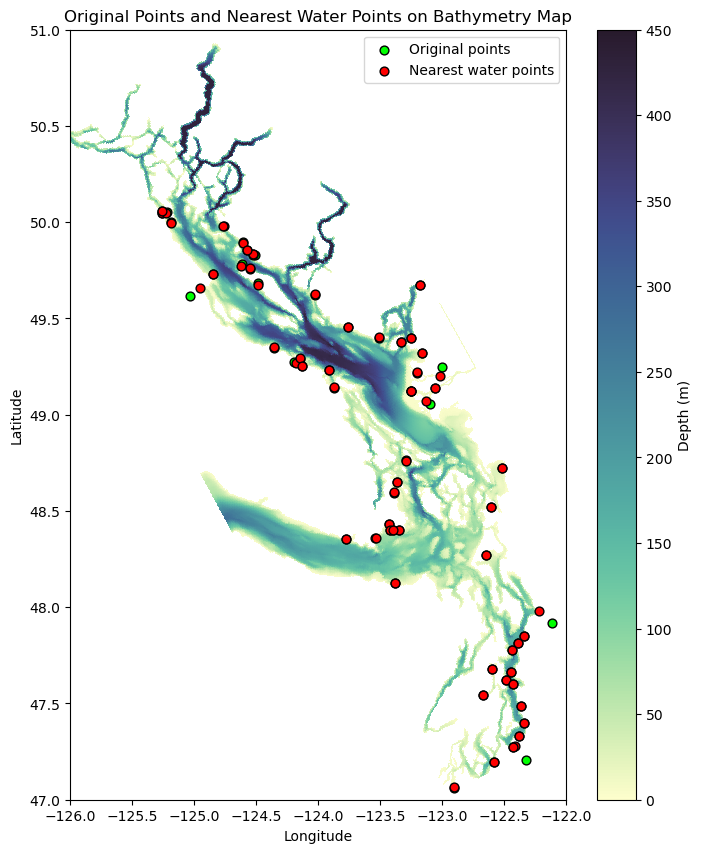

In [69]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh_plot = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(canada_plot["lon"],canada_plot["lat"],color="lime",edgecolors="black",s=40,label="Original points")
ax.scatter(canada_plot["nearest_lon"],canada_plot["nearest_lat"],color="red",edgecolors="black",s=40,label="Nearest water points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-126, -122)
ax.set_ylim(47, 51)
ax.set_title("Original Points and Nearest Water Points on Bathymetry Map")
ax.legend()

plt.colorbar(mesh_plot, ax=ax, label="Depth (m)")
plt.show()

/tmp/ipykernel_720652/2188127439.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh_plot = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


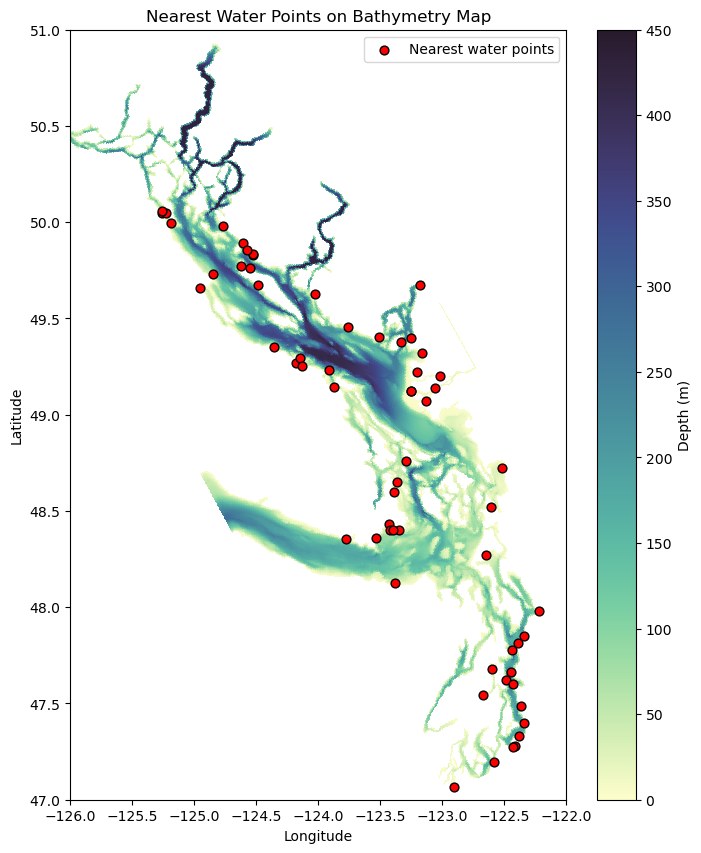

In [70]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh_plot = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(canada_plot["nearest_lon"],canada_plot["nearest_lat"],color="red",edgecolors="black",s=40,label="Nearest water points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-126, -122)
ax.set_ylim(47, 51)
ax.set_title("Nearest Water Points on Bathymetry Map")
ax.legend()

plt.colorbar(mesh_plot, ax=ax, label="Depth (m)")
plt.show()

/tmp/ipykernel_720652/3530465244.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


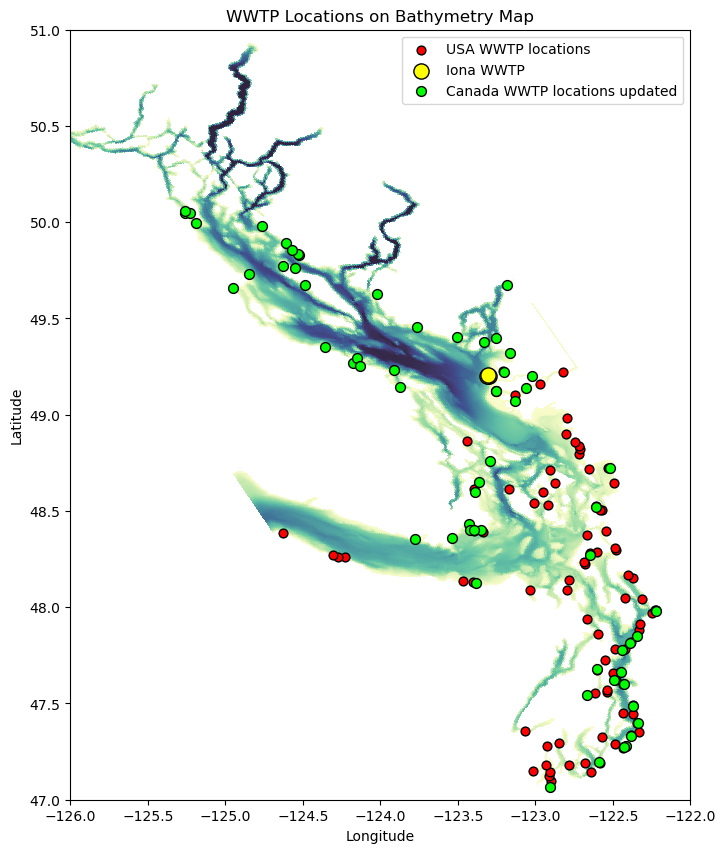

In [71]:
fig, ax = plt.subplots(figsize=(8, 10))

mesh = ax.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

ax.scatter(wwtp_locs["lon"],wwtp_locs["lat"],color="red",edgecolors="black",s=40,label="USA WWTP locations")
ax.scatter(iona_lon,iona_lat,color="yellow",edgecolor="black",s=120,label="Iona WWTP")
ax.scatter(canada_plot["nearest_lon"],canada_plot["nearest_lat"],color="lime",edgecolor="black",s=50,label="Canada WWTP locations updated")
ax.set_xlabel("Longitude")
ax.set_xlim(-126, -122)
ax.set_ylabel("Latitude")
ax.set_ylim(47, 51)
ax.set_title("WWTP Locations on Bathymetry Map")
ax.legend()
plt.show()


In [72]:
file_canada.head()

,Outfall Name from Valenti-Muelas et al. (2026),Outfall Name from Rich,Population,lat,lon,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,nearest_usa_distance_km
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.510335
1,NaN,BC Ferries,NaN,49.783333,-124.616670,3,"0,31",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.598319
2,NaN,Van Anda,NaN,49.758333,-124.550000,35,"17,2",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.080158
3,NaN,District of Campbell River,35519.0,50.048611,-125.258333,35,20000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.887412
4,NaN,Powell River Regional District - Lund,NaN,49.981111,-124.761111,50,70,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.283728


In [73]:
file_canada = file_canada.rename(columns={
    "Outfall Name from Rich": "Name",
})

In [74]:
file_canada.head()

,Outfall Name from Valenti-Muelas et al. (2026),Name,Population,lat,lon,Depth,Flow,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,nearest_usa_distance_km
0,NaN,Capital Regional District - Clover Point,NaN,48.402500,-123.348889,67,44915,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.510335
1,NaN,BC Ferries,NaN,49.783333,-124.616670,3,"0,31",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.598319
2,NaN,Van Anda,NaN,49.758333,-124.550000,35,"17,2",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.080158
3,NaN,District of Campbell River,35519.0,50.048611,-125.258333,35,20000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.887412
4,NaN,Powell River Regional District - Lund,NaN,49.981111,-124.761111,50,70,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.283728


In [75]:
points = {}
for _,row in file_canada.iterrows():
    points[row["Name"]] = (row["lon"],row["lat"])
points

{'Capital Regional District - Clover Point': (-123.348889, 48.4025),
 'BC Ferries': (-124.61667, 49.783333),
 'Van Anda': (-124.55, 49.758333),
 'District of Campbell River': (-125.258333, 50.048611),
 'Powell River Regional District - Lund': (-124.7611111, 49.9811111),
 'Quathiaski Cove': (-125.217, 50.051),
 'Sliammon': (-124.6083333, 49.8969444),
 'Sundowner': (-124.025259, 49.62253832),
 'Cape Mudge Band': (-125.18444, 49.99972),
 'Cumberland': (-125.03613, 49.61634),
 'Gillies Bay': (-124.48333, 49.683333),
 'Wildwood': (-124.513893, 49.830452),
 'Nanoose FN': (-124.193054, 49.272316),
 'Westview': (-124.528876410001, 49.8371656881596),
 'Town of Gibsons WWTP': (-123.50912417875, 49.4005691328716),
 'Snug Cove WWTP': (-123.332078459847, 49.3796392381716),
 'Citrus Wynd WWTP': (-123.250249795345, 49.3974552422354),
 'Riverport WWTP': (-123.060988116488, 49.1363763192682),
 'TFN Sewage Treatment Plant': (-123.098053077777, 49.053303965667),
 'French Creek Pollution Control': (-124.3

In [76]:
print(len(points))

61


In [77]:
print(len(file_canada))

62


In [78]:
grid_dir = Path("/ocean/atall/MOAD/grid/")


NameError: name 'Path' is not defined